# İkinci El Araç Fiyat Tahmini — Regresyon Projesi

**Veri seti:** `cars.csv` — Türkiye ikinci el otomobil ilan verileri (~52 400 satır, 23 sütun)

**Hedef değişken:** `fiyat` (TL cinsinden sürekli değer)

**Proje adımları:**
1. Keşifsel Veri Analizi (EDA)
2. Veri Temizleme ve Ayrıştırma (Parse)
3. Özellik Mühendisliği
4. Train / Test Ayrımı
5. Ön-işleme Pipeline'ı
6. Baseline ve Gelişmiş Modeller
7. Değerlendirme (MAE, RMSE, R²)
8. Özellik Önemi ve Hata Analizi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import warnings, re
from IPython.display import display
from scipy.stats import randint, uniform
from sklearn.base import clone

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 1. Veri Yükleme ve İlk Bakış

In [2]:
df = pd.read_csv("cars.csv", encoding="utf-8")
print(f"Boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
df.head(3)

Boyut: 52256 satır × 23 sütun


,baslik,konum,fiyat,ilan_tarihi,marka,seri,model,yil,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,cekis,arac_durumu,ortalama_yakit_tuketimi,yakit_deposu,boya_degisen,takasa_uygun,kimden,tramer
0,2022 MEGANE 1.3 TCE 140 HP JOY COMFORT EDC SER...,"Yeni Mh. Sarıçam, Adana",1.169.000 TL,21 Ağustos 2025,Renault,Megane,1.3 TCe Joy Comfort,2022,124.000 km,Otomatik,Benzin,Sedan,Beyaz,1201 - 1400 cm3,126 - 150 HP,Önden Çekiş,İkinci El,NaN,NaN,1 değişen,Takasa Uygun,Galeriden,71300.0
1,2022 SKODA OCTAVİA 1.0 E-TEC ELİTE DSG SERVİS ...,"Yeni Mh. Sarıçam, Adana",1.520.000 TL,21 Ağustos 2025,Skoda,Octavia,1.0 e-Tec Elite,2022,99.000 km,Otomatik,Hibrit,Sedan,Gri,1201 - 1400 cm3,101 - 125 HP,Önden Çekiş,İkinci El,NaN,NaN,1 boyalı,Takasa Uygun,Galeriden,56060.0
2,Sahibinden HATASIZ BOYASIZ Peugeot 207,"Cemalpaşa Mh. Seyhan, Adana",469.999 TL,19 Ağustos 2025,Peugeot,207,1.4 Trendy,2009,207.500 km,Düz,LPG & Benzin,Hatchback/5,Gri,1360 cc,91 hp,Önden Çekiş,İkinci El,"6,3 lt",50 lt,Tamamı orjinal,Takasa Uygun,Sahibinden,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52256 entries, 0 to 52255
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   baslik                   52256 non-null  str    
 1   konum                    52256 non-null  str    
 2   fiyat                    52256 non-null  str    
 3   ilan_tarihi              52256 non-null  str    
 4   marka                    52256 non-null  str    
 5   seri                     52256 non-null  str    
 6   model                    52185 non-null  str    
 7   yil                      52256 non-null  int64  
 8   kilometre                52255 non-null  str    
 9   vites_tipi               52244 non-null  str    
 10  yakit_tipi               52256 non-null  str    
 11  kasa_tipi                52252 non-null  str    
 12  renk                     52254 non-null  str    
 13  motor_hacmi              51103 non-null  str    
 14  motor_gucu               50895 no

## 2. Sütun Bazlı Profil: Tip, Örnek Değer, Eksik %, Benzersiz Sayı

In [4]:
profile = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "nunique": df.nunique(),
    "sample_value": df.iloc[0].values,
})
profile

,dtype,non_null,null_count,null_pct,nunique,sample_value
baslik,str,52256,0,0.00,37537,2022 MEGANE 1.3 TCE 140 HP JOY COMFORT EDC SER...
konum,str,52256,0,0.00,9174,"Yeni Mh. Sarıçam, Adana"
fiyat,str,52256,0,0.00,3951,1.169.000 TL
ilan_tarihi,str,52256,0,0.00,161,21 Ağustos 2025
marka,str,52256,0,0.00,59,Renault
seri,str,52256,0,0.00,423,Megane
model,str,52185,71,0.14,2951,1.3 TCe Joy Comfort
yil,int64,52256,0,0.00,54,2022
kilometre,str,52255,1,0.00,4802,124.000 km
vites_tipi,str,52244,12,0.02,3,Otomatik


In [5]:
print("=== Kategorik sütunlardaki benzersiz değerler (ilk 10) ===\n")
cat_cols = ["marka", "seri", "vites_tipi", "yakit_tipi", "kasa_tipi",
            "renk", "cekis", "arac_durumu", "takasa_uygun", "kimden"]
for col in cat_cols:
    vc = df[col].value_counts().head(10)
    print(f"--- {col} ({df[col].nunique()} benzersiz) ---")
    print(vc.to_string(), "\n")

=== Kategorik sütunlardaki benzersiz değerler (ilk 10) ===

--- marka (59 benzersiz) ---
marka
Renault            8563
Volkswagen         6185
Fiat               5633
Opel               5284
Ford               3756
Hyundai            2900
Toyota             2737
Peugeot            2010
BMW                1955
Mercedes - Benz    1848 

--- seri (423 benzersiz) ---
seri
Astra      2686
Clio       2461
Megane     2243
Corolla    2129
Passat     2065
Focus      2035
Egea       1874
Polo       1492
Corsa      1421
Civic      1329 

--- vites_tipi (3 benzersiz) ---
vites_tipi
Düz              33003
Otomatik         15351
Yarı Otomatik     3890 

--- yakit_tipi (5 benzersiz) ---
yakit_tipi
Benzin          18709
Dizel           18522
LPG & Benzin    14417
Hibrit            397
Elektrik          211 

--- kasa_tipi (11 benzersiz) ---
kasa_tipi
Sedan            29787
Hatchback/5      18763
Station wagon     1275
Hatchback/3        905
MPV                718
Coupe              610
-              

In [6]:
print("=== Sayısal / parse gerektiren sütunlar — örnek değerler ===\n")
for col in ["fiyat", "kilometre", "motor_hacmi", "motor_gucu",
            "ortalama_yakit_tuketimi", "yakit_deposu", "tramer", "boya_degisen"]:
    print(f"--- {col} ---")
    print(df[col].dropna().sample(min(8, df[col].dropna().shape[0]), random_state=42).values, "\n")

=== Sayısal / parse gerektiren sütunlar — örnek değerler ===

--- fiyat ---
<StringArray>
[  '750.000 TL',   '559.000 TL',   '305.000 TL',   '466.500 TL',
   '610.000 TL',   '415.000 TL', '5.400.000 TL',   '500.000 TL']
Length: 8, dtype: str 

--- kilometre ---
<StringArray>
['248.000 km', '215.000 km', '182.000 km', '326.000 km', '246.000 km',
 '240.000 km', '347.000 km', '188.000 km']
Length: 8, dtype: str 

--- motor_hacmi ---
<StringArray>
[        '1368 cc',         '1596 cc',         '1500 cc', '1401 - 1600 cm3',
 '1401 - 1600 cm3', '1401 - 1600 cm3',         '1598 cc',         '1390 cc']
Length: 8, dtype: str 

--- motor_gucu ---
<StringArray>
[      '125 hp',        '60 hp', '126 - 150 HP',  '76 - 100 HP',
  '76 - 100 HP', '101 - 125 HP',        '90 hp',       '122 hp']
Length: 8, dtype: str 

--- ortalama_yakit_tuketimi ---
<StringArray>
['3,4 lt', '4,9 lt', '7,7 lt', '5,6 lt', '7,7 lt', '4,7 lt', '6 lt', '5,1 lt']
Length: 8, dtype: str 

--- yakit_deposu ---
<StringArray>
['6

## 3. Eksik Veri Haritası

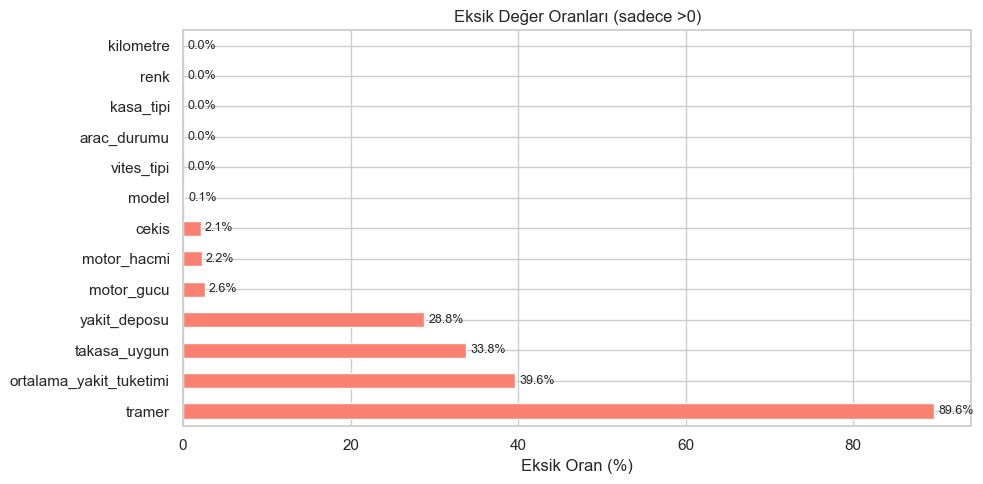

In [7]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
null_pct.plot.barh(ax=ax, color="salmon")
ax.set_xlabel("Eksik Oran (%)")
ax.set_title("Eksik Değer Oranları (sadece >0)")
for i, v in enumerate(null_pct.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
dup_subset = ["marka", "seri", "yil", "kilometre", "fiyat"]
dup_count = df.duplicated(subset=dup_subset).sum()
print(f"Olası yinelenen ilan sayısı (marka+seri+yıl+km+fiyat eşleşmesi): {dup_count}")
print(f"Toplam satır: {len(df)}")
print(f"Yinelenen oran: %{dup_count / len(df) * 100:.2f}")

_n = len(df)
df = df.drop_duplicates(subset=dup_subset, keep="first").reset_index(drop=True)
print(f"Yinelenen temizliği sonrası: {_n} → {len(df)} satır")

Olası yinelenen ilan sayısı (marka+seri+yıl+km+fiyat eşleşmesi): 378
Toplam satır: 52256
Yinelenen oran: %0.72
Yinelenen temizliği sonrası: 52256 → 51878 satır


## 4. Veri Temizleme ve Ayrıştırma (Parse)

Sayısal olması gereken ama string halinde bulunan sütunları temizliyoruz:
- `fiyat`: `1.169.000 TL` → `1169000`
- `kilometre`: `124.000 km` → `124000`
- `motor_hacmi`: `1368 cc` veya `1201 - 1400 cm3` → orta değer
- `motor_gucu`: `91 hp` veya `76 - 100 HP` → orta değer
- `ortalama_yakit_tuketimi`: `6,3 lt` → `6.3`
- `yakit_deposu`: `50 lt` → `50`
- `boya_degisen`: boyalı ve değişen parça sayısı çıkarılacak

In [9]:
def parse_fiyat(val):
    """'1.169.000 TL' → 1169000"""
    if pd.isna(val):
        return np.nan
    s = str(val).replace(".", "").replace("TL", "").strip()
    try:
        return int(s)
    except ValueError:
        return np.nan

def parse_km(val):
    """'124.000 km' → 124000"""
    if pd.isna(val):
        return np.nan
    s = str(val).replace(".", "").replace("km", "").strip()
    try:
        return int(s)
    except ValueError:
        return np.nan

def parse_motor_hacmi(val):
    """'1368 cc' → 1368 veya '1201 - 1400 cm3' → 1300.5 (orta değer)"""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    nums = re.findall(r"\d+", s)
    if len(nums) == 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return np.nan

def parse_motor_gucu(val):
    """'91 hp' → 91 veya '76 - 100 HP' → 88"""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    nums = re.findall(r"\d+", s)
    if len(nums) == 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return np.nan

def parse_yakit_tuketim(val):
    """'6,3 lt' → 6.3"""
    if pd.isna(val):
        return np.nan
    s = str(val).replace(",", ".").replace("lt", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

def parse_yakit_deposu(val):
    """'50 lt' → 50"""
    if pd.isna(val):
        return np.nan
    s = str(val).replace("lt", "").strip()
    try:
        return int(s)
    except ValueError:
        return np.nan

def parse_boya_degisen(val):
    """Boyalı ve değişen parça sayısını çıkarır. 'Tamamı orjinal' → (0,0)"""
    boyali, degisen = 0, 0
    if pd.isna(val):
        return np.nan, np.nan
    s = str(val).lower().strip()
    if "tamamı orjinal" in s:
        return 0, 0
    if "tamamı boyalı" in s:
        return 10, 0  # tüm paneller
    if "belirtilmemiş" in s:
        return np.nan, np.nan

    m_boyali = re.search(r"(\d+)\s*boyalı", s)
    m_degisen = re.search(r"(\d+)\s*değişen", s)
    if m_boyali:
        boyali = int(m_boyali.group(1))
    if m_degisen:
        degisen = int(m_degisen.group(1))
    return boyali, degisen

print("Parse fonksiyonları tanımlandı.")

Parse fonksiyonları tanımlandı.


In [10]:
df["fiyat_num"] = df["fiyat"].apply(parse_fiyat)
df["km_num"] = df["kilometre"].apply(parse_km)
df["motor_hacmi_num"] = df["motor_hacmi"].apply(parse_motor_hacmi)
df["motor_gucu_num"] = df["motor_gucu"].apply(parse_motor_gucu)
df["yakit_tuketim_num"] = df["ortalama_yakit_tuketimi"].apply(parse_yakit_tuketim)
df["yakit_deposu_num"] = df["yakit_deposu"].apply(parse_yakit_deposu)

boya_parsed = df["boya_degisen"].apply(parse_boya_degisen)
df["boyali_sayi"] = boya_parsed.apply(lambda x: x[0])
df["degisen_sayi"] = boya_parsed.apply(lambda x: x[1])

df["tramer_num"] = df["tramer"].fillna(0)

print("Parse sonrası yeni sütunlar:")
print(df[["fiyat_num", "km_num", "motor_hacmi_num", "motor_gucu_num",
          "yakit_tuketim_num", "yakit_deposu_num", "boyali_sayi",
          "degisen_sayi", "tramer_num"]].describe().round(2))

Parse sonrası yeni sütunlar:
          fiyat_num       km_num  motor_hacmi_num  motor_gucu_num  \
count  5.187800e+04     51877.00         39996.00        50414.00   
mean   7.629638e+05    207641.36          1456.85          106.95   
std    2.193548e+06    524986.31           300.89           37.24   
min    1.000000e+04         0.00           601.50           41.00   
25%    3.500000e+05    130000.00          1364.00           88.00   
50%    5.790000e+05    200000.00          1490.00          100.00   
75%    9.450000e+05    266000.00          1597.00          115.00   
max    4.670000e+08  99999999.00          6592.00          761.00   

       yakit_tuketim_num  yakit_deposu_num  boyali_sayi  degisen_sayi  \
count           31335.00          36925.00     41435.00      41435.00   
mean                5.72             52.28         2.62          0.54   
std                 1.36              7.56         3.31          0.91   
min                 0.80             30.00         0.00  

In [11]:
print(f"Parse sonrası eksik sayıları:")
for col in ["fiyat_num", "km_num", "motor_hacmi_num", "motor_gucu_num",
            "yakit_tuketim_num", "yakit_deposu_num", "boyali_sayi", "degisen_sayi"]:
    n = df[col].isna().sum()
    print(f"  {col}: {n} ({n/len(df)*100:.2f}%)")

Parse sonrası eksik sayıları:
  fiyat_num: 0 (0.00%)
  km_num: 1 (0.00%)
  motor_hacmi_num: 11882 (22.90%)
  motor_gucu_num: 1464 (2.82%)
  yakit_tuketim_num: 20543 (39.60%)
  yakit_deposu_num: 14953 (28.82%)
  boyali_sayi: 10443 (20.13%)
  degisen_sayi: 10443 (20.13%)


### 4b. Özet: Bu aşamada yapılan ön işleme

| Adım | Açıklama |
|------|----------|
| Yinelenen ilanlar | Aynı marka/seri/yıl/km/fiyat ile tekrarlayan satırlar silindi (ilk kayıt kaldı). |
| Parse | Fiyat, km, motor ve boya metinleri sayısal sütunlara dönüştürüldü; `tramer` için eksik → 0 (`tramer_num`). |
| Model matrisi (`dfm`) | Geçersiz hedef, eksik yıl/km, mantık dışı yıl/km ve kategorik yer tutucular temizlendi; `konum`→`il`/`ilce`; `tramer_eksik`; `seri`/`model` dahil. |
| Eksik değerler | Sayısal alanlarda `SimpleImputer(median)`, düşük kard. kategorikte `most_frequent`+OHE, yüksek kard. için `TargetEncoder` (pipeline içinde). |
| Fiyat aykırıları | **Yalnızca** train/test ayrımından sonra, eşikler `y_train` quantile ile (P1–P99). |
| Hiperparametre | HistGradientBoosting için `RandomizedSearchCV` (tuning sonrası `best_pipe`). |

## 5. Parse Sonrası Dağılımlar ve Görselleştirme

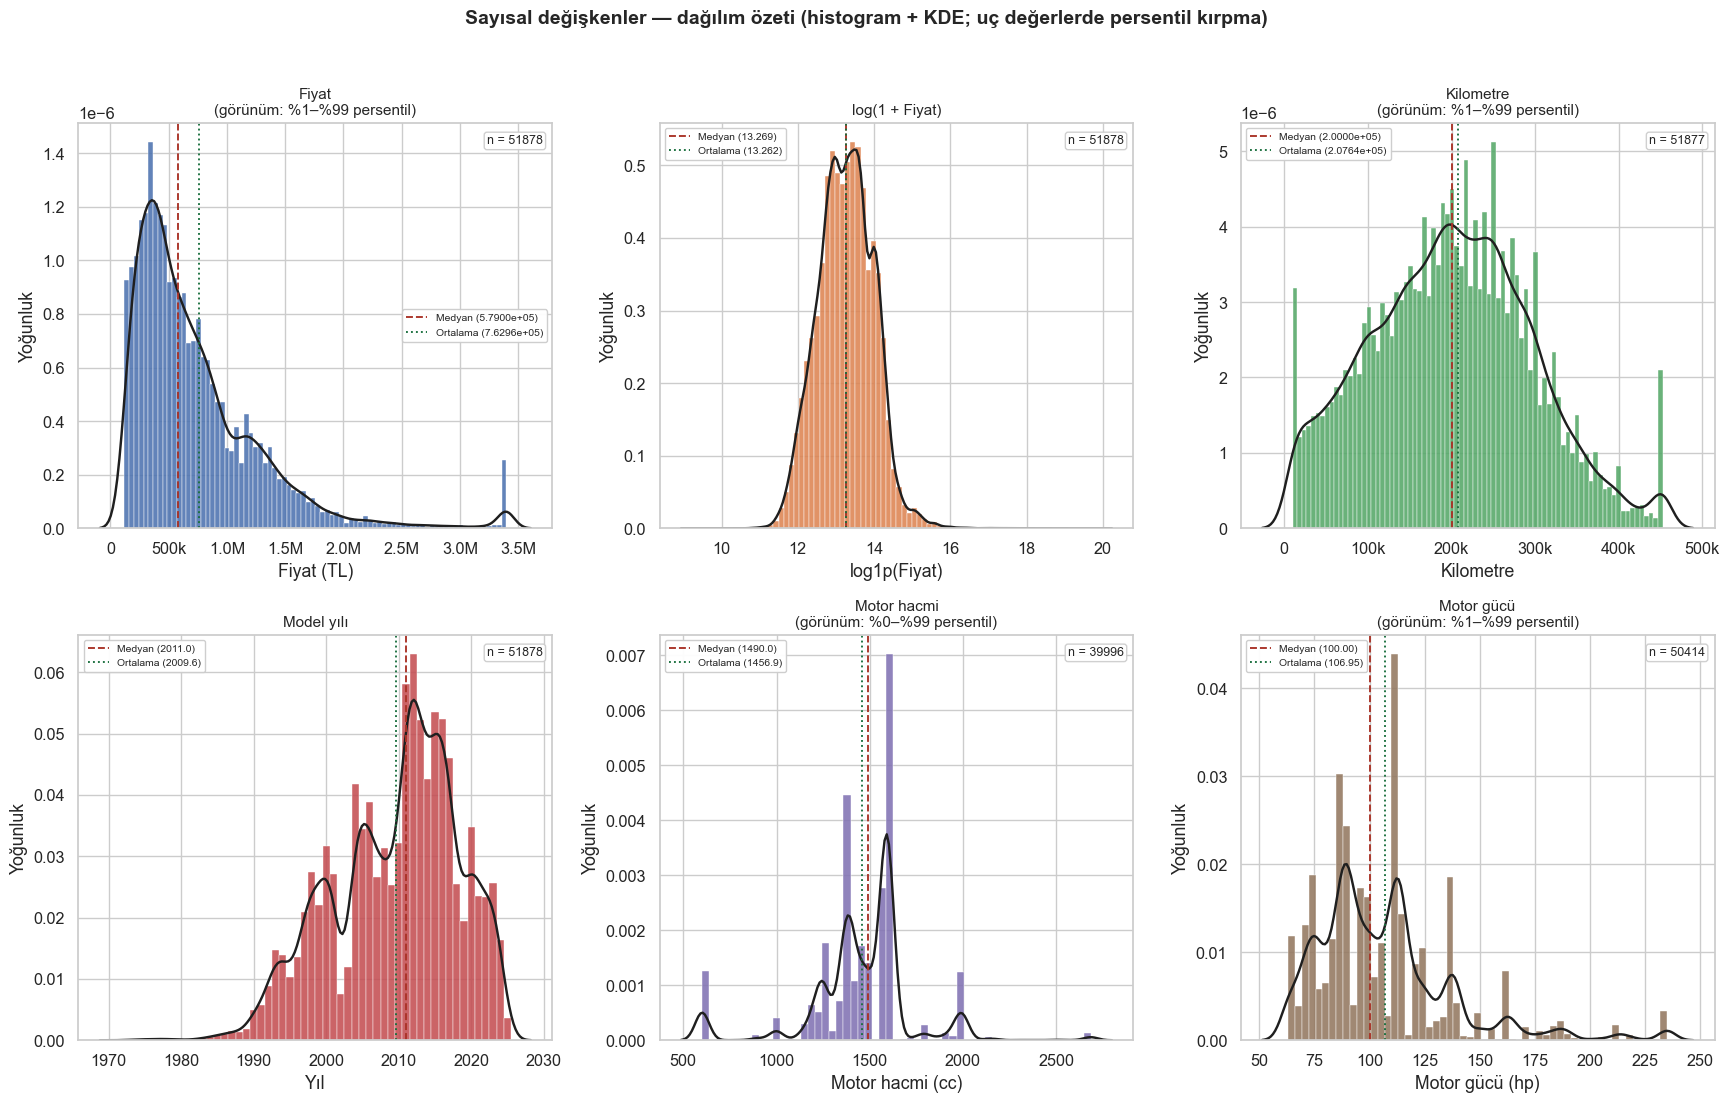

In [12]:
from matplotlib.ticker import FuncFormatter


def _tl_axis_fmt(x, _pos):
    ax = abs(x)
    if ax >= 1e6:
        return f"{x/1e6:.1f}M"
    if ax >= 1e3:
        return f"{x/1e3:.0f}k"
    return f"{x:.0f}"


def _stat_label(v):
    if not np.isfinite(v):
        return "—"
    return f"{v:#.5g}"


def _density_hist(ax, values, title, xlabel, color, bins=70, q_clip=None, xfmt=None):
    """Histogram + KDE; q_clip=(düşük, yüksek) persentil ile sadece görüntüyü kırpar (istatistikler ham veriden)."""
    v = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    n = len(v)
    if n == 0:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Veri yok", ha="center", va="center", transform=ax.transAxes)
        return
    subtitle = ""
    if q_clip is not None:
        lo, hi = np.quantile(v, list(q_clip))
        vp = np.clip(v, lo, hi)
        subtitle = f"\n(görünüm: %{int(q_clip[0] * 100)}–%{int(q_clip[1] * 100)} persentil)"
    else:
        vp = v
    ax.hist(vp, bins=bins, color=color, edgecolor="white", linewidth=0.35, density=True, alpha=0.88)
    if np.unique(vp).size > 1 and len(vp) > 5:
        sns.kdeplot(x=vp, ax=ax, color="0.12", lw=1.75, bw_adjust=1.1)
    med, mean = float(np.median(v)), float(np.mean(v))
    ax.axvline(med, color="#a93226", ls="--", lw=1.35, label=f"Medyan ({_stat_label(med)})")
    ax.axvline(mean, color="#196f3d", ls=":", lw=1.35, label=f"Ortalama ({_stat_label(mean)})")
    ax.set_title(title + subtitle, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Yoğunluk")
    if xfmt is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
    ax.legend(fontsize=7.5, loc="best", framealpha=0.95)
    ax.text(
        0.98,
        0.97,
        f"n = {n}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="#cccccc", alpha=0.92),
    )


palette = sns.color_palette("deep", n_colors=6)

with sns.plotting_context("notebook", font_scale=1.06), sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 3, figsize=(17.5, 10.8))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Sayısal değişkenler — dağılım özeti (histogram + KDE; uç değerlerde persentil kırpma)",
        fontsize=14,
        fontweight="semibold",
        y=1.02,
    )

    _density_hist(
        axes[0, 0],
        df["fiyat_num"],
        "Fiyat",
        "Fiyat (TL)",
        palette[0],
        bins=80,
        q_clip=(0.01, 0.99),
        xfmt=_tl_axis_fmt,
    )

    lf = np.log1p(pd.to_numeric(df["fiyat_num"], errors="coerce").dropna())
    lf = lf[np.isfinite(lf)]
    _density_hist(axes[0, 1], lf, "log(1 + Fiyat)", "log1p(Fiyat)", palette[1], bins=80)

    _density_hist(
        axes[0, 2],
        df["km_num"],
        "Kilometre",
        "Kilometre",
        palette[2],
        bins=80,
        q_clip=(0.01, 0.99),
        xfmt=_tl_axis_fmt,
    )

    y = pd.to_numeric(df["yil"], errors="coerce").dropna()
    y = y[np.isfinite(y)].astype(int)
    y_min, y_max = int(y.min()), int(y.max())
    year_bins = np.arange(y_min, y_max + 2) - 0.5
    _density_hist(axes[1, 0], y, "Model yılı", "Yıl", palette[3], bins=year_bins)

    _density_hist(
        axes[1, 1],
        df["motor_hacmi_num"],
        "Motor hacmi",
        "Motor hacmi (cc)",
        palette[4],
        bins=55,
        q_clip=(0.005, 0.995),
    )

    _density_hist(
        axes[1, 2],
        df["motor_gucu_num"],
        "Motor gücü",
        "Motor gücü (hp)",
        palette[5],
        bins=55,
        q_clip=(0.01, 0.99),
    )

    fig.tight_layout()

plt.show()

### Bu grafikler ne anlatıyor?
Bu **2×3** panel, veri setindeki seçili **sayısal değişkenlerin dağılımını** gösterir. Her alt grafikte renkli **histogram** (dikdörtgenler) ve üzerine binen ince **KDE** çizgisi (*Kernel Density Estimate*, yoğunluğun pürüzsüz tahmini) vardır.
#### Eksenler
| Eksen | Anlamı |
|--------|--------|
| **x (yatay)** | İlgili değişkenin değeri: fiyat (TL), `log1p(fiyat)`, kilometre, model yılı, motor hacmi (cc), motor gücü (hp). Fiyat/km panellerinde okunabilirlik için eksen bazen **k** (bin) veya **M** (milyon) ile kısaltılabilir. |
| **y (dikey), “Yoğunluk”** | Histogram **`density=True`** ile çizildiği için burada **olasılık yoğunluğu** vardır; bu, “bu aralıkta kaç gözlem var?” sayısı değil, **normalize** bir ölçektir. Her çubuğun **(genişlik × yükseklik)** değeri o aralıktaki veri oranıyla ilişkilidir; tüm çubukların alanı toplamı **1** olacak şekilde ölçeklenir. KDE çizgisi de aynı yoğunluk ölçeğindedir. |
#### Çizgiler ve notlar
- **Kırmızı kesik:** Ham verideki **medyan**.
- **Yeşil noktalı:** Ham verideki **ortalama** (aritmetik).
- Başlıkta **“görünüm: %…–%… persentil”** yazıyorsa, histogram yalnızca **görsel** için uç değerler bu persentillerle **kırpılmış** veriyle çizilir; medyan ve ortalama yine **tüm geçerli gözlemlerden** hesaplanır.
- **Sağ üst `n = …`:** O panelde kullanılan gözlem sayısı.
#### Paneller (soldan sağa, üstten alta)
1. **Fiyat (TL)** — fiyat dağılımı (genelde uç aykırılar için persentil kırpma ile).  
2. **log(1 + Fiyat)** — log dönüşümü; sağa çarpık fiyatı daha dengeli okumak için.  
3. **Kilometre** — km dağılımı.  
4. **Model yılı** — yıllara göre yoğunluk.  
5. **Motor hacmi (cc)** — silindir hacmi dağılımı.  
6. **Motor gücü (hp)** — beygir gücü dağılımı.


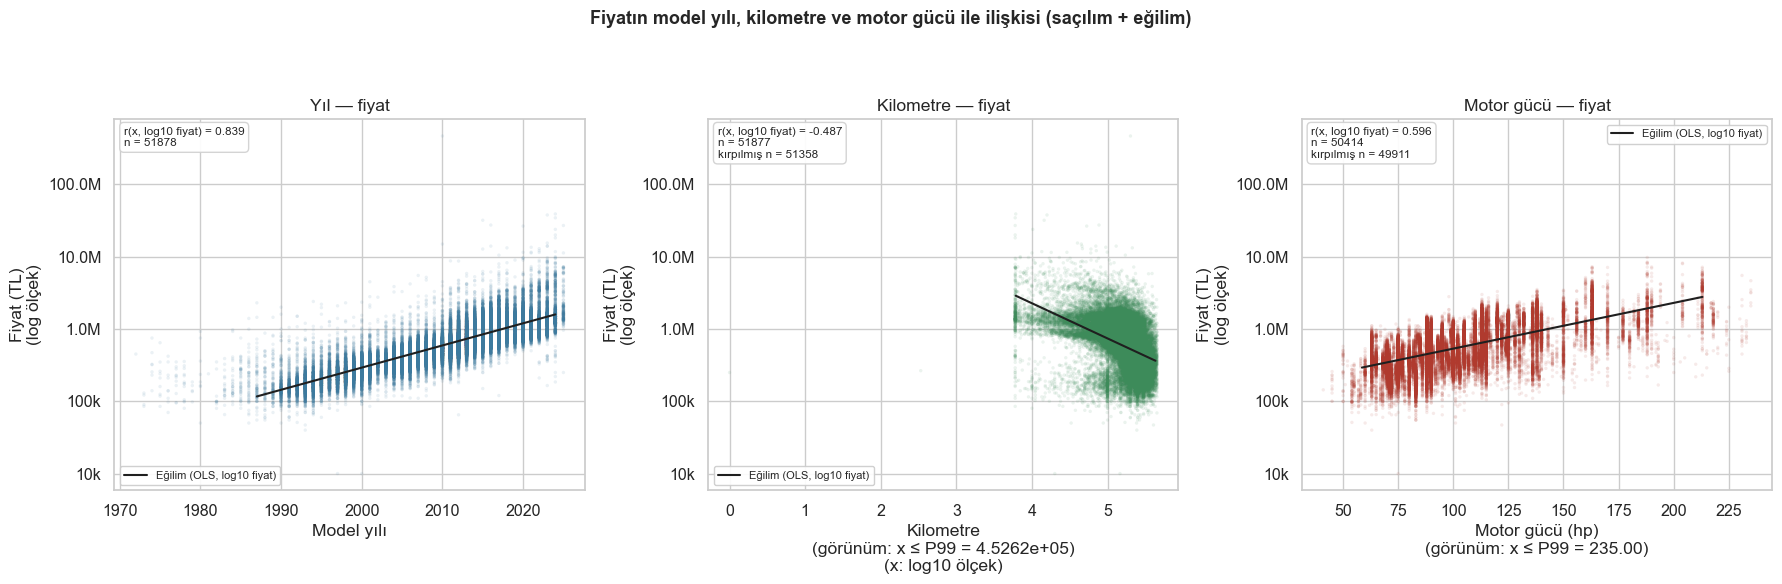

In [13]:
from matplotlib.ticker import FuncFormatter


def _tl_money(y, _pos):
    if y >= 1e6:
        return f"{y/1e6:.1f}M"
    if y >= 1e3:
        return f"{y/1e3:.0f}k"
    return f"{y:.0f}"


def _scatter_fiyat_panel(
    ax,
    x,
    y,
    xlabel,
    title,
    color,
    *,
    clip_x_quantile=None,
    log_x=False,
):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y) & (y > 0)
    x = x[ok].to_numpy()
    y = y[ok].to_numpy()
    n_full = len(y)
    note_lines = [f"n = {n_full}"]
    if clip_x_quantile is not None and len(x):
        x_hi = float(np.quantile(x, clip_x_quantile))
        m = x <= x_hi
        x, y = x[m], y[m]
        pct = int(round(clip_x_quantile * 100))
        xlabel = f"{xlabel}\n(görünüm: x ≤ P{pct} = {x_hi:#.5g})"
        note_lines.append(f"kırpılmış n = {len(y)}")
    if len(y) == 0:
        ax.text(0.5, 0.5, "Veri yok", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    if log_x:
        x = np.maximum(x, 1.0)
        x_plot = np.log10(x)
        xlabel = f"{xlabel}\n(x: log10 ölçek)"
    else:
        x_plot = x
    ax.scatter(
        x_plot,
        y,
        s=6,
        alpha=0.1,
        c=color,
        edgecolors="none",
        linewidths=0,
        rasterized=True,
    )
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(_tl_money))
    ax.set_ylabel("Fiyat (TL)\n(log ölçek)")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ly = np.log10(y)
    if np.unique(x_plot).size > 1 and len(x_plot) > 20:
        coef = np.polyfit(x_plot, ly, 1)
        xs = np.linspace(np.nanpercentile(x_plot, 0.5), np.nanpercentile(x_plot, 99.5), 250)
        ax.plot(
            xs,
            10 ** np.polyval(coef, xs),
            color="0.12",
            lw=1.5,
            zorder=3,
            label="Eğilim (OLS, log10 fiyat)",
        )
        r = np.corrcoef(x_plot, ly)[0, 1]
        r_txt = f"r(x, log10 fiyat) = {r:.3f}" if np.isfinite(r) else "r = —"
        ax.legend(loc="best", fontsize=8, framealpha=0.92)
    else:
        r_txt = "r = —"
    ax.text(
        0.02,
        0.98,
        r_txt + "\n" + "\n".join(note_lines),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.82", alpha=0.93),
    )


with sns.plotting_context("notebook", font_scale=1.05), sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Fiyatın model yılı, kilometre ve motor gücü ile ilişkisi (saçılım + eğilim)",
        fontsize=13,
        fontweight="semibold",
        y=1.06,
    )

    _scatter_fiyat_panel(
        axes[0],
        df["yil"],
        df["fiyat_num"],
        "Model yılı",
        "Yıl — fiyat",
        "#3d7a9e",
        clip_x_quantile=None,
        log_x=False,
    )
    _scatter_fiyat_panel(
        axes[1],
        df["km_num"],
        df["fiyat_num"],
        "Kilometre",
        "Kilometre — fiyat",
        "#3d8b5a",
        clip_x_quantile=0.99,
        log_x=True,
    )
    _scatter_fiyat_panel(
        axes[2],
        df["motor_gucu_num"],
        df["fiyat_num"],
        "Motor gücü (hp)",
        "Motor gücü — fiyat",
        "#b03a2e",
        clip_x_quantile=0.99,
        log_x=False,
    )

    fig.tight_layout()

plt.show()

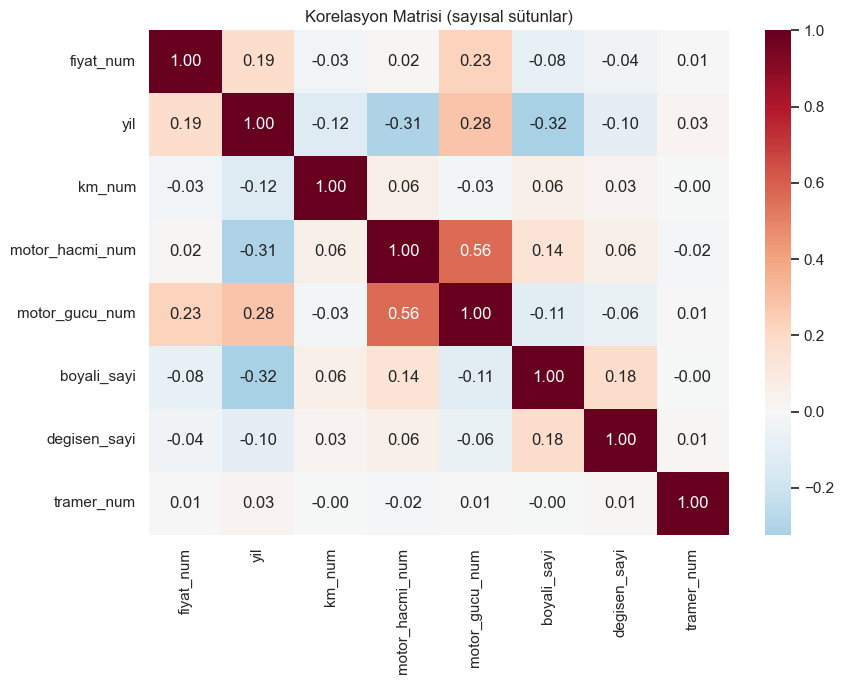

In [14]:
num_cols = ["fiyat_num", "yil", "km_num", "motor_hacmi_num", "motor_gucu_num",
            "boyali_sayi", "degisen_sayi", "tramer_num"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Korelasyon Matrisi (sayısal sütunlar)")
plt.tight_layout()
plt.show()

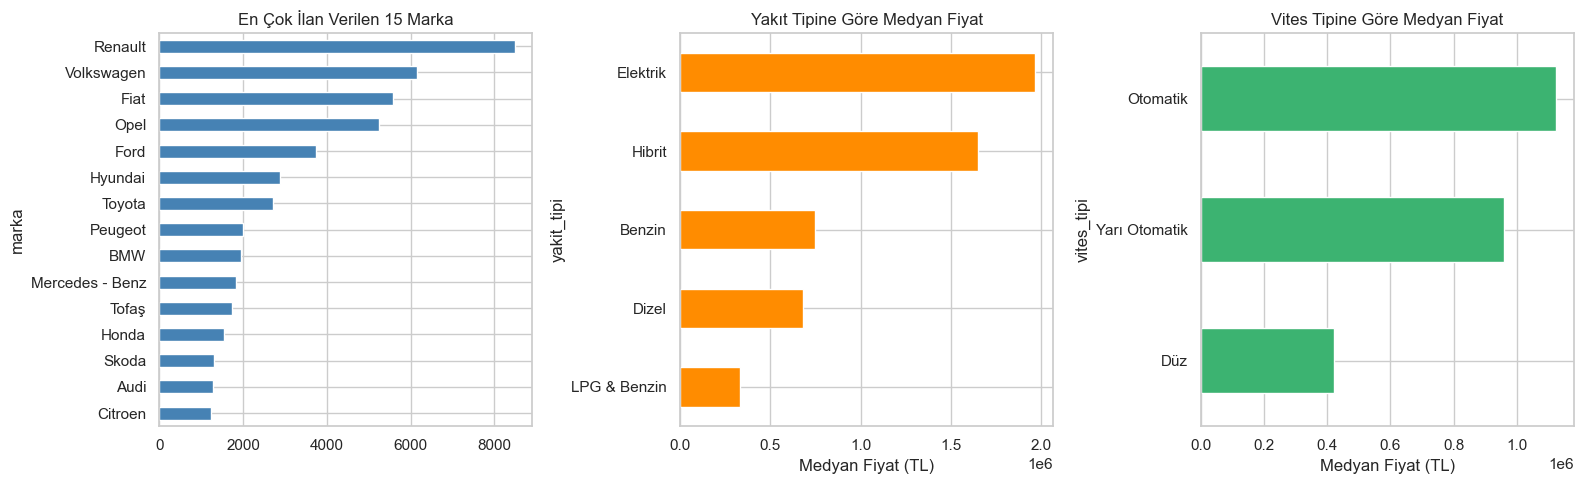

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top_marka = df["marka"].value_counts().head(15)
top_marka.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("En Çok İlan Verilen 15 Marka")
axes[0].invert_yaxis()

df.groupby("yakit_tipi")["fiyat_num"].median().sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Yakıt Tipine Göre Medyan Fiyat")
axes[1].set_xlabel("Medyan Fiyat (TL)")

df.groupby("vites_tipi")["fiyat_num"].median().sort_values().plot.barh(ax=axes[2], color="mediumseagreen")
axes[2].set_title("Vites Tipine Göre Medyan Fiyat")
axes[2].set_xlabel("Medyan Fiyat (TL)")

plt.tight_layout()
plt.show()

## 6. Özellik Seçimi ve Temiz Veri Seti Oluşturma

Modelleme için kullanılacak sütunlar:

**Sayısal:** `yil`, `km_num`, `motor_hacmi_num`, `motor_gucu_num`, `boyali_sayi`, `degisen_sayi`, `tramer_num`, `tramer_eksik` (ham `tramer` eksikliği göstergesi)

**Kategorik (OHE):** `marka`, `vites_tipi`, `yakit_tipi`, `kasa_tipi`, `cekis`, `kimden`, `il` (`konum`dan türetildi)

**Yüksek kardinalite (TargetEncoder):** `seri`, `model`, `ilce` (`konum`dan türetildi)

**Hariç tutulanlar:**
- `baslik`: sızıntı riski + yüksek kardinalite
- `konum`: ham metin; yerine `il` / `ilce` kullanıldı
- `arac_durumu`: neredeyse tamamı "İkinci El"
- `ortalama_yakit_tuketimi`, `yakit_deposu`: %30-40 eksik
- `takasa_uygun`: %34 eksik
- `ilan_tarihi`, `renk`: ileri aşama iyileştirme için bırakıldı

In [16]:
def parse_il_ilce(konum):
    """Örn. 'Yeni Mh. Sarıçam, Adana' → il=Adana, ilce=Sarıçam (veya sol segment)."""
    if pd.isna(konum):
        return pd.Series([np.nan, np.nan], index=["il", "ilce"])
    s = str(konum).strip()
    if not s or "," not in s:
        return pd.Series([np.nan, np.nan], index=["il", "ilce"])
    left, il = s.rsplit(",", 1)
    il = il.strip()
    left = left.strip()
    if not il:
        return pd.Series([np.nan, np.nan], index=["il", "ilce"])
    m = re.search(r"Mh\.\s*(.+)$", left, flags=re.IGNORECASE)
    ilce = m.group(1).strip() if m else left
    if not ilce:
        ilce = np.nan
    return pd.Series([il, ilce], index=["il", "ilce"])


numeric_features = ["yil", "km_num", "motor_hacmi_num", "motor_gucu_num",
                    "boyali_sayi", "degisen_sayi", "tramer_num", "tramer_eksik"]
categorical_features = ["marka", "vites_tipi", "yakit_tipi", "kasa_tipi", "cekis", "kimden", "il"]
target_enc_features = ["seri", "model", "ilce"]
target = "fiyat_num"

df_work = df.copy()
df_work[["il", "ilce"]] = df_work["konum"].apply(parse_il_ilce)
if "tramer" in df_work.columns:
    df_work["tramer_eksik"] = df_work["tramer"].isna().astype("int8")
else:
    df_work["tramer_eksik"] = df_work["tramer_num"].isna().astype("int8")

keep_cols = numeric_features + categorical_features + target_enc_features + [target]
missing = [c for c in keep_cols if c not in df_work.columns]
if missing:
    raise ValueError(f"Eksik sütunlar: {missing}")

dfm = df_work[keep_cols].copy()

print(f"Seçilen sütunlarla boyut: {dfm.shape}")
print(f"Hedef (fiyat_num) eksik: {dfm[target].isna().sum()}")

dfm = dfm.dropna(subset=[target])
dfm = dfm[dfm[target] > 0]
print(f"Hedef NaN/0 temizliği sonrası: {dfm.shape[0]} satır")

before = len(dfm)
dfm = dfm.dropna(subset=["yil", "km_num"])
print(f"yıl / km eksik temizliği: {before} → {len(dfm)} satır (çıkarılan: {before - len(dfm)})")

YIL_MIN, YIL_MAX = 1980, int(pd.Timestamp.now().year) + 1
KM_MAX = 2_000_000
before = len(dfm)
mask_ok = (
    (dfm["yil"] >= YIL_MIN) & (dfm["yil"] <= YIL_MAX)
    & (dfm["km_num"] >= 0) & (dfm["km_num"] <= KM_MAX)
)
dfm = dfm.loc[mask_ok].copy()
print(f"Mantık dışı yıl ({YIL_MIN}–{YIL_MAX}) veya km (0–{KM_MAX:,}): {before} → {len(dfm)} satır")

str_cols = categorical_features + target_enc_features
for col in str_cols:
    dfm[col] = dfm[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    dfm[col] = dfm[col].replace("", np.nan)

cat_dash_cols = ["cekis", "kasa_tipi"]
for col in cat_dash_cols:
    dfm[col] = dfm[col].replace("-", np.nan)

all_feature_cols = numeric_features + categorical_features + target_enc_features

print(f"Fiyat aralığı (train öncesi, P1–P99 sonraki hücrede): {dfm[target].min():,.0f} – {dfm[target].max():,.0f} TL")
print(f"\nModelleme öncesi son boyut: {dfm.shape}")

print("\n--- Ön işleme sonrası kontrol (dfm) ---")
dfm.info()
na_pct = (dfm.isna().sum() / len(dfm) * 100).round(2)
na_ozet = pd.DataFrame({"eksik_adet": dfm.isna().sum(), "eksik_yuzde": na_pct})
na_ozet = na_ozet[na_ozet["eksik_adet"] > 0].sort_values("eksik_adet", ascending=False)
print("Eksik değer özeti (yalnızca eksik > 0):")
if len(na_ozet):
    display(na_ozet)
else:
    print("Tüm sütunlarda eksik yok.")
dfm.head()

Seçilen sütunlarla boyut: (51878, 19)
Hedef (fiyat_num) eksik: 0
Hedef NaN/0 temizliği sonrası: 51878 satır
yıl / km eksik temizliği: 51878 → 51877 satır (çıkarılan: 1)
Mantık dışı yıl (1980–2027) veya km (0–2,000,000): 51877 → 51789 satır
Fiyat aralığı (train öncesi, P1–P99 sonraki hücrede): 10,000 – 467,000,000 TL

Modelleme öncesi son boyut: (51789, 19)

--- Ön işleme sonrası kontrol (dfm) ---
<class 'pandas.DataFrame'>
Index: 51789 entries, 0 to 51877
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   yil              51789 non-null  int64  
 1   km_num           51789 non-null  float64
 2   motor_hacmi_num  39927 non-null  float64
 3   motor_gucu_num   50332 non-null  float64
 4   boyali_sayi      41388 non-null  float64
 5   degisen_sayi     41388 non-null  float64
 6   tramer_num       51789 non-null  float64
 7   tramer_eksik     51789 non-null  int8   
 8   marka            51789 non-null  str    
 

,eksik_adet,eksik_yuzde
motor_hacmi_num,11862,22.90
boyali_sayi,10401,20.08
degisen_sayi,10401,20.08
motor_gucu_num,1457,2.81
cekis,1193,2.30
model,69,0.13
kasa_tipi,67,0.13
vites_tipi,11,0.02


,yil,km_num,motor_hacmi_num,motor_gucu_num,boyali_sayi,degisen_sayi,tramer_num,tramer_eksik,marka,vites_tipi,yakit_tipi,kasa_tipi,cekis,kimden,il,seri,model,ilce,fiyat_num
0,2022,124000.0,NaN,138.0,0.0,1.0,71300.0,0,Renault,Otomatik,Benzin,Sedan,Önden Çekiş,Galeriden,Adana,Megane,1.3 TCe Joy Comfort,Sarıçam,1169000
1,2022,99000.0,NaN,113.0,1.0,0.0,56060.0,0,Skoda,Otomatik,Hibrit,Sedan,Önden Çekiş,Galeriden,Adana,Octavia,1.0 e-Tec Elite,Sarıçam,1520000
2,2009,207500.0,1360.0,91.0,0.0,0.0,0.0,1,Peugeot,Düz,LPG & Benzin,Hatchback/5,Önden Çekiş,Sahibinden,Adana,207,1.4 Trendy,Seyhan,469999
3,2013,219000.0,NaN,188.0,4.0,1.0,0.0,1,Audi,Otomatik,Dizel,Sedan,4WD (Sürekli),Galeriden,Adana,A4,A4 Sedan 2.0 TDI Quattro,Seyhan,1150000
4,2013,335000.0,NaN,188.0,0.0,0.0,0.0,1,BMW,Otomatik,Benzin,Sedan,Arkadan İtiş,Galeriden,Adana,5 Serisi,520Li,Seyhan,1359000


## 7. Train / Test Ayrımı

In [17]:
X = dfm[all_feature_cols]
y = dfm[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

p_lo, p_hi = float(y_train.quantile(0.01)), float(y_train.quantile(0.99))
train_mask = (y_train >= p_lo) & (y_train <= p_hi)
test_mask = (y_test >= p_lo) & (y_test <= p_hi)
before_tr, before_te = len(X_train), len(X_test)
X_train, y_train = X_train.loc[train_mask], y_train.loc[train_mask]
X_test, y_test = X_test.loc[test_mask], y_test.loc[test_mask]
print(f"Fiyat P1–P99 filtresi (eşikler yalnızca y_train'den): [{p_lo:,.0f}, {p_hi:,.0f}] TL")
print(f"  Train: {before_tr} → {len(X_train)} | Test: {before_te} → {len(X_test)}")

print(f"Train: {X_train.shape[0]} satır")
print(f"Test:  {X_test.shape[0]} satır")
print(f"Hedef ortalaması — Train: {y_train.mean():,.0f} TL | Test: {y_test.mean():,.0f} TL")

# CV / permutation için: yalnızca P1–P99 sonrası kalan satırlar
X = pd.concat([X_train, X_test]).sort_index()
y = pd.concat([y_train, y_test]).sort_index()

Fiyat P1–P99 filtresi (eşikler yalnızca y_train'den): [120,000, 3,395,000] TL
  Train: 41431 → 40653 | Test: 10358 → 10161
Train: 40653 satır
Test:  10161 satır
Hedef ortalaması — Train: 712,450 TL | Test: 711,781 TL


## 8. Ön-işleme Pipeline ve Modelleme

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

target_enc_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(random_state=42, cv=5)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("te", target_enc_transformer, target_enc_features),
])

print("Preprocessor tanımlandı.")
print(f"  Sayısal ({len(numeric_features)}): {numeric_features}")
print(f"  Kategorik OHE ({len(categorical_features)}): {categorical_features}")
print(f"  TargetEncoder ({len(target_enc_features)}): {target_enc_features}")

Preprocessor tanımlandı.
  Sayısal (8): ['yil', 'km_num', 'motor_hacmi_num', 'motor_gucu_num', 'boyali_sayi', 'degisen_sayi', 'tramer_num', 'tramer_eksik']
  Kategorik OHE (7): ['marka', 'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'cekis', 'kimden', 'il']
  TargetEncoder (3): ['seri', 'model', 'ilce']


In [19]:
_prep_check = clone(preprocessor)
_Xt = _prep_check.fit_transform(X_train, y_train)
_feat_names = _prep_check.get_feature_names_out()
_Xt_df = pd.DataFrame(_Xt, columns=_feat_names, index=X_train.index)

print("Preprocess sonrası veri (transform edilmiş) — ilk 5 satır:")
display(_Xt_df.head())
print(f"Transform sonrası NaN var mı? {_Xt_df.isna().any().any()}")

Preprocess sonrası veri (transform edilmiş) — ilk 5 satır:


,num__yil,num__km_num,num__motor_hacmi_num,num__motor_gucu_num,num__boyali_sayi,num__degisen_sayi,num__tramer_num,num__tramer_eksik,cat__marka_Alfa Romeo,cat__marka_Anadol,cat__marka_Audi,cat__marka_BMW,cat__marka_BYD,cat__marka_Cadillac,cat__marka_Chery,...,te__ilce_3319000,te__ilce_3320000,te__ilce_3325000,te__ilce_3330000,te__ilce_3335000,te__ilce_3340000,te__ilce_3349000,te__ilce_3350000,te__ilce_3360000,te__ilce_3370000,te__ilce_3375000,te__ilce_3379000,te__ilce_3389000,te__ilce_3390000,te__ilce_3395000
22700,1.242050,-0.518602,0.554535,0.963959,-0.434341,-0.515294,-0.03487,0.343567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8552,0.035179,-0.147159,-0.217245,-0.269256,0.227364,0.665422,-0.03487,-2.910637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
21291,0.276553,-0.072870,-0.802867,-0.332497,0.227364,0.665422,-0.03487,0.343567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000031,0.000031,0.000061,0.000092,0.0,0.000061,0.000031,0.000154,0.0,0.000061,0.000123,0.000031,0.000031,0.000031,0.000092
14805,0.638614,-0.582985,-0.802867,-0.332497,-0.765194,-0.515294,-0.03487,0.343567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000243,0.0,0.000000,0.000122,0.000000,0.0,0.000122,0.000243,0.000000,0.000000,0.000000,0.000000
13273,1.362737,-1.532888,-1.768562,-0.174393,-0.765194,-0.515294,-0.03487,0.343567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Transform sonrası NaN var mı? False


In [20]:
from sklearn import set_config
set_config(display="diagram")  # Jupyter'da pipeline şeması
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [21]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Modeli eğit, test et, metrikleri döndür."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = root_mean_squared_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    print(f"{name:35s} | MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "pipeline": model}

print("evaluate_model() tanımlandı.")

evaluate_model() tanımlandı.


### 8a. Baseline: DummyRegressor (ortalama tahmini)

In [22]:
results = []

dummy_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])
results.append(evaluate_model("Baseline (Ortalama)", dummy_pipe, X_train, y_train, X_test, y_test))

Baseline (Ortalama)                 | MAE:      378,693 | RMSE:      497,451 | R²: -0.0000


### 8b. Ridge Regression

In [23]:
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])
results.append(evaluate_model("Ridge Regression", ridge_pipe, X_train, y_train, X_test, y_test))

Ridge Regression                    | MAE:      109,338 | RMSE:      171,935 | R²: 0.8805


### 8c. ElasticNet

In [24]:
enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000)),
])
results.append(evaluate_model("ElasticNet", enet_pipe, X_train, y_train, X_test, y_test))

ElasticNet                          | MAE:      161,463 | RMSE:      254,014 | R²: 0.7393


### 8d. Random Forest

In [ ]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                                     n_jobs=-1, random_state=42)),
])
results.append(evaluate_model("Random Forest", rf_pipe, X_train, y_train, X_test, y_test))

### 8e. HistGradientBoosting (sklearn built-in, XGBoost benzeri)

In [26]:
hgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(max_iter=500, max_depth=8,
                                            learning_rate=0.05, random_state=42)),
])
results.append(evaluate_model("HistGradientBoosting", hgb_pipe, X_train, y_train, X_test, y_test))

HistGradientBoosting                | MAE:       58,217 | RMSE:       95,249 | R²: 0.9633


### 8f. HistGradientBoosting — RandomizedSearchCV (hiperparametre araması)

In [27]:
hgb_tune_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42)),
])
param_dist = {
    "model__max_iter": randint(300, 900),
    "model__max_depth": randint(4, 14),
    "model__learning_rate": uniform(0.03, 0.12),
    "model__min_samples_leaf": randint(10, 60),
    "model__l2_regularization": uniform(0.0, 0.6),
}
hgb_search = RandomizedSearchCV(
    hgb_tune_base,
    param_distributions=param_dist,
    n_iter=22,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
hgb_search.fit(X_train, y_train)
print("En iyi parametreler:", hgb_search.best_params_)
tuned_hgb = clone(hgb_search.best_estimator_)
results.append(evaluate_model("HistGBT (RandomizedSearch)", tuned_hgb, X_train, y_train, X_test, y_test))
best_pipe = tuned_hgb

Fitting 3 folds for each of 22 candidates, totalling 66 fits
En iyi parametreler: {'model__l2_regularization': np.float64(0.45647102917013843), 'model__learning_rate': np.float64(0.09735326370833955), 'model__max_depth': 10, 'model__max_iter': 692, 'model__min_samples_leaf': 24}
HistGBT (RandomizedSearch)          | MAE:       58,719 | RMSE:       95,962 | R²: 0.9628


## 9. Model Karşılaştırma Tablosu

In [28]:
results_df = pd.DataFrame(results).drop(columns=["pipeline"])
results_df["MAE"] = results_df["MAE"].apply(lambda x: f"{x:,.0f}")
results_df["RMSE"] = results_df["RMSE"].apply(lambda x: f"{x:,.0f}")
results_df["R2"] = results_df["R2"].apply(lambda x: f"{x:.4f}")
results_df.set_index("model", inplace=True)
results_df

,MAE,RMSE,R2
model,,,
Baseline (Ortalama),"378,693","497,451",-0.0000
Ridge Regression,"109,338","171,935",0.8805
ElasticNet,"161,463","254,014",0.7393
HistGradientBoosting,"58,217","95,249",0.9633
HistGBT (RandomizedSearch),"58,719","95,962",0.9628


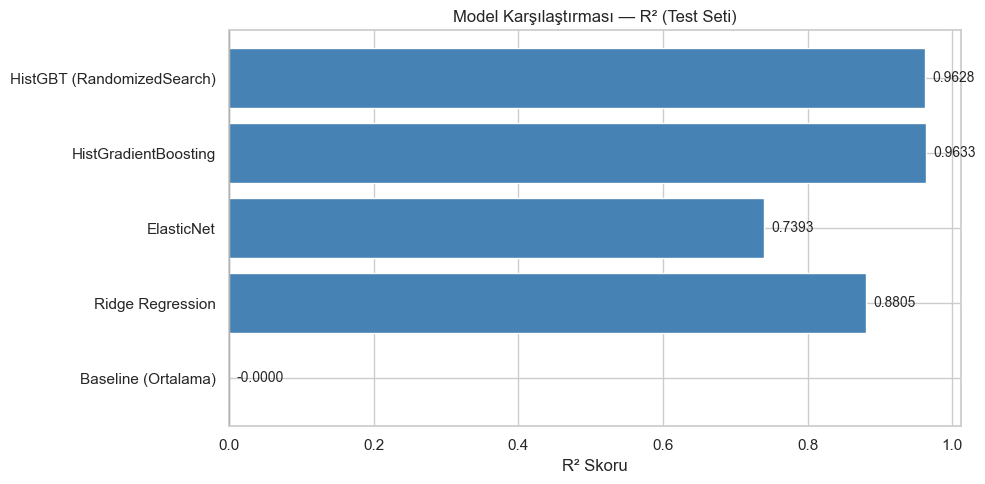

In [29]:
r2_vals = [r["R2"] for r in results]
model_names = [r["model"] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["grey" if v < 0 else "steelblue" for v in r2_vals]
bars = ax.barh(model_names, r2_vals, color=colors, edgecolor="white")
ax.set_xlabel("R² Skoru")
ax.set_title("Model Karşılaştırması — R² (Test Seti)")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### Cross-Validation: Tuning sonrası seçilen pipeline (HistGradientBoosting) — 5-Fold CV

In [ ]:
cv_r2 = cross_val_score(best_pipe, X, y, cv=5, scoring="r2", n_jobs=-1)
cv_mae = -cross_val_score(best_pipe, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)

print("5-Fold Cross-Validation Sonuçları (best_pipe, tuning sonrası):")
print(f"  R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  (fold'lar: {np.round(cv_r2, 4)})")
print(f"  MAE : {cv_mae.mean():,.0f} ± {cv_mae.std():,.0f}  (fold'lar: {np.round(cv_mae, 0)})")

## 10. Özellik Önemi ve Hata Analizi

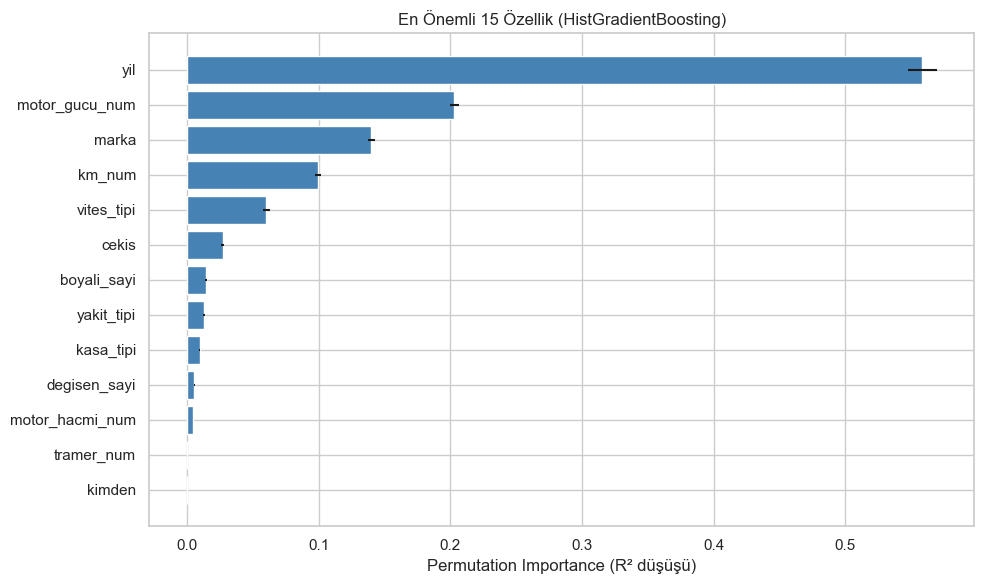

,feature,importance_mean,importance_std
0,yil,0.558576,0.010756
3,motor_gucu_num,0.203227,0.003090
7,marka,0.140108,0.002530
1,km_num,0.099568,0.002328
8,vites_tipi,0.060430,0.002344
11,cekis,0.027394,0.001145
4,boyali_sayi,0.014742,0.000843
9,yakit_tipi,0.012968,0.000511
10,kasa_tipi,0.009711,0.000525
5,degisen_sayi,0.005739,0.000520


In [ ]:
from sklearn.inspection import permutation_importance

best_pipe.fit(X_train, y_train)

perm_imp = permutation_importance(best_pipe, X_test, y_test,
                                   n_repeats=10, random_state=42, n_jobs=-1)

feat_names = all_feature_cols
imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm_imp.importances_mean,
    "importance_std": perm_imp.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_n = imp_df.head(15)
ax.barh(top_n["feature"], top_n["importance_mean"],
        xerr=top_n["importance_std"], color="steelblue", edgecolor="white")
ax.set_xlabel("Permutation Importance (R² düşüşü)")
ax.set_title("En Önemli 15 Özellik (HistGradientBoosting)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

imp_df.head(15)

### Hata Analizi: Gerçek vs Tahmin

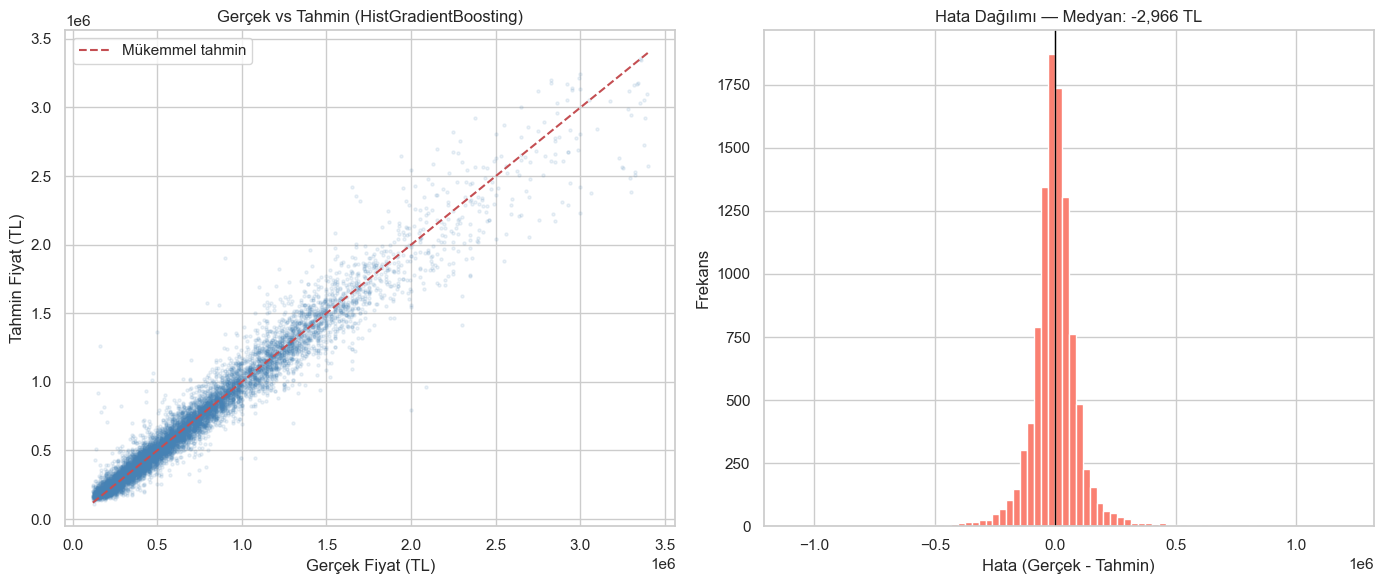

In [ ]:
y_pred_best = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_best, alpha=0.1, s=5, color="steelblue")
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Mükemmel tahmin")
axes[0].set_xlabel("Gerçek Fiyat (TL)")
axes[0].set_ylabel("Tahmin Fiyat (TL)")
axes[0].set_title("Gerçek vs Tahmin (HistGradientBoosting)")
axes[0].legend()

errors = y_test - y_pred_best
axes[1].hist(errors, bins=80, color="salmon", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Hata (Gerçek - Tahmin)")
axes[1].set_ylabel("Frekans")
axes[1].set_title(f"Hata Dağılımı — Medyan: {np.median(errors):,.0f} TL")

plt.tight_layout()
plt.show()

In [ ]:
error_df = X_test.copy()
error_df["gercek_fiyat"] = y_test.values
error_df["tahmin_fiyat"] = y_pred_best
error_df["hata"] = error_df["gercek_fiyat"] - error_df["tahmin_fiyat"]
error_df["abs_hata"] = error_df["hata"].abs()

print("=== En kötü 10 tahmin (en yüksek mutlak hata) ===")
worst = error_df.nlargest(10, "abs_hata")[
    ["marka", "yil", "km_num", "motor_gucu_num", "gercek_fiyat", "tahmin_fiyat", "hata"]
]


def _fmt_tl(x):
    """TL tutarını bilimsel gösterim olmadan yaz (örn. 1.234.567 TL)."""
    if pd.isna(x):
        return ""
    return f"{int(round(float(x))):,}".replace(",", ".") + " TL"


def _fmt_sayi(x):
    """km / hp gibi sayıları noktalı binlik ayırıcıyla göster."""
    if pd.isna(x):
        return ""
    return f"{int(round(float(x))):,}".replace(",", ".")


worst_goster = worst.copy()
worst_goster["km_num"] = worst_goster["km_num"].apply(_fmt_sayi)
worst_goster["motor_gucu_num"] = worst_goster["motor_gucu_num"].apply(_fmt_sayi)
for col in ["gercek_fiyat", "tahmin_fiyat", "hata"]:
    worst_goster[col] = worst[col].apply(_fmt_tl)

worst_goster

=== En kötü 10 tahmin (en yüksek mutlak hata) ===


,marka,yil,km_num,motor_gucu_num,gercek_fiyat,tahmin_fiyat,hata
41063,Volkswagen,2007,320.000,225,1.999.999 TL,793.349 TL,1.206.650 TL
47656,Mercedes - Benz,1997,187.000,231,2.090.000 TL,960.450 TL,1.129.550 TL
41039,Regal Raptor,2023,6.000,,165.000 TL,1.259.504 TL,-1.094.504 TL
40958,BMW,2004,167.000,272,900.000 TL,1.903.714 TL,-1.003.714 TL
43702,Volkswagen,2020,13.000,120,3.300.000 TL,2.386.544 TL,913.456 TL
42063,Mercedes - Benz,1998,389.000,238,2.300.000 TL,1.416.552 TL,883.448 TL
32884,Volvo,2002,202.000,272,500.000 TL,1.365.892 TL,-865.892 TL
46358,Audi,2019,179.000,213,3.397.500 TL,2.576.233 TL,821.267 TL
12924,Skoda,2024,15.000,138,3.325.000 TL,2.506.657 TL,818.343 TL
7388,Mercedes - Benz,2013,190.000,263,3.295.000 TL,2.485.036 TL,809.964 TL


## 11. Tekil Araç Fiyat Tahmini

**Hemen alttaki kod hücresini** çalıştırın. `ornek_arac` sözlüğünü kendi aracınıza göre düzenleyin. Kategorik alanlar (`marka`, `seri`, `model`, `il`, `ilce`, `vites_tipi`, vb.) eğitim verisinde geçen değerlerle **aynı yazım** olmalıdır. `tramer_eksik`: 1 = ham tramer bilgisi yoktu; 0 = vardı (veya biliniyor).

In [ ]:
def fmt_tl_cikti(tutar_tl):
    """Tahmin çıktısını okunaklı TL stringine çevirir."""
    return f"{int(round(float(tutar_tl))):,}".replace(",", ".") + " TL"


def arac_fiyat_tahmini(
    yil,
    km_num,
    motor_hacmi_num,
    motor_gucu_num,
    marka,
    seri,
    model,
    il,
    ilce=None,
    vites_tipi="Otomatik",
    yakit_tipi="Benzin",
    kasa_tipi="Sedan",
    cekis="Önden Çekiş",
    kimden="Galeriden",
    boyali_sayi=0.0,
    degisen_sayi=0.0,
    tramer_num=0.0,
    tramer_eksik=0,
):
    """
    Eğitilmiş best_pipe ile tahmin. Kategorik değerler veri setindeki etiketlerle aynı yazılmalı.
    """
    satir = {
        "yil": int(yil),
        "km_num": float(km_num),
        "motor_hacmi_num": float(motor_hacmi_num) if motor_hacmi_num is not None else np.nan,
        "motor_gucu_num": float(motor_gucu_num) if motor_gucu_num is not None else np.nan,
        "boyali_sayi": float(boyali_sayi),
        "degisen_sayi": float(degisen_sayi),
        "tramer_num": float(tramer_num),
        "tramer_eksik": int(tramer_eksik),
        "marka": marka,
        "seri": seri,
        "model": model,
        "il": il,
        "ilce": ilce if ilce is not None else np.nan,
        "vites_tipi": vites_tipi,
        "yakit_tipi": yakit_tipi,
        "kasa_tipi": kasa_tipi,
        "cekis": cekis,
        "kimden": kimden,
    }
    X_new = pd.DataFrame([satir])[all_feature_cols]
    return float(best_pipe.predict(X_new)[0])


# --- Burayı düzenleyin ---
ornek_arac = {
    "yil": 2019,
    "km_num": 85_000,
    "motor_hacmi_num": 1598,
    "motor_gucu_num": 150,
    "marka": "BMW",
    "seri": "3 Serisi",
    "model": "320i",
    "il": "İstanbul",
    "ilce": "Kadıköy",
    "vites_tipi": "Otomatik",
    "yakit_tipi": "Benzin",
    "kasa_tipi": "Sedan",
    "cekis": "Önden Çekiş",
    "kimden": "Galeriden",
    "boyali_sayi": 0,
    "degisen_sayi": 0,
    "tramer_num": 0,
    "tramer_eksik": 0,
}

tahmin = arac_fiyat_tahmini(**ornek_arac)
print("Tahmini fiyat:", fmt_tl_cikti(tahmin))
print("\nİpucu — veri setinde geçen markalar (ilk 30):")
print(sorted(dfm["marka"].unique())[:30])

Tahmini fiyat: 1.808.174 TL

İpucu — veri setinde geçen markalar (ilk 30):
['Alfa Romeo', 'Anadol', 'Audi', 'BMW', 'BYD', 'Cadillac', 'Chery', 'Chevrolet', 'Chrysler', 'Citroen', 'Cupra', 'DS Automobiles', 'Dacia', 'Daewoo', 'Daihatsu', 'Fiat', 'Ford', 'Geely', 'Honda', 'Hyundai', 'Ikco', 'Infiniti', 'Jaguar', 'Kia', 'Lada', 'Lancia', 'MG', 'Maserati', 'Mazda', 'Mercedes - Benz']


In [ ]:
# `fmt_tl_cikti` ve `arac_fiyat_tahmini` bir üst hücrede tanımlı.
ornek_arac_2 = {
    "yil": 2004,
    "km_num": 185_000,
    "motor_hacmi_num": 1998,
    "motor_gucu_num": 150,
    "marka": "BMW",
    "seri": "3 Serisi",
    "model": "320i",
    "il": "Ankara",
    "ilce": "Çankaya",
    "vites_tipi": "Otomatik",
    "yakit_tipi": "Benzin",
    "kasa_tipi": "Sedan",
    "cekis": "Önden Çekiş",
    "kimden": "Galeriden",
    "boyali_sayi": 0,
    "degisen_sayi": 0,
    "tramer_num": 0,
    "tramer_eksik": 0,
}

tahmin2 = arac_fiyat_tahmini(**ornek_arac_2)
print("Tahmini fiyat (örnek 2):", fmt_tl_cikti(tahmin2))

Tahmini fiyat: 627.209 TL

İpucu — veri setinde geçen markalar (ilk 30):
['Alfa Romeo', 'Anadol', 'Audi', 'BMW', 'BYD', 'Cadillac', 'Chery', 'Chevrolet', 'Chrysler', 'Citroen', 'Cupra', 'DS Automobiles', 'Dacia', 'Daewoo', 'Daihatsu', 'Fiat', 'Ford', 'Geely', 'Honda', 'Hyundai', 'Ikco', 'Infiniti', 'Jaguar', 'Kia', 'Lada', 'Lancia', 'MG', 'Maserati', 'Mazda', 'Mercedes - Benz']


## 12. Sonuç ve Değerlendirme

**Proje özeti:**
- Yaklaşık **52.000** satırlık ikinci el araç ilan verisiyle **sürekli hedef** (`fiyat`) üzerinde regresyon yapıldı.
- **Veri temizliği ve ön işleme:** Yinelenen ilanlar (marka, seri, yıl, kilometre metni, fiyat metni aynı olanlar) çıkarıldı. Fiyat, km, motor ve boya alanları **parse** edilerek sayısallaştırıldı; `tramer` eksikleri `tramer_num` için 0 kabul edildi. Modelleme matrisinde (`dfm`) geçersiz/sıfır fiyat, eksik yıl veya km, mantık dışı yıl (1980–gelecek yıl+1) ve km (0–2.000.000) dışı kayıtlar elendi; kategoriklerde boşluk/`"-"` düzeltmesi yapıldı.
- **Train/test** ayrımından sonra fiyat **P1–P99** kesimi yalnızca **`y_train` quantile** ile tanımlandı; test tarafı aynı eşiklerle süzüldü. Ön işlemede **median + StandardScaler** (sayısal), **OneHotEncoder** (düşük kardinaliteli kategorik + `il`), **TargetEncoder** (`seri`, `model`, `ilce`) kullanıldı.
- **Özellik seti:** 8 sayısal (arada `tramer_eksik`), 7 kategorik OHE, 3 sütun target encoding; modeller: Dummy, Ridge, ElasticNet, Random Forest, HistGradientBoosting ve **RandomizedSearchCV** ile ayarlanmış HistGBT; **5-fold CV** tuning sonrası `best_pipe` üzerinde.

**Temel bulgular:**
- **`yil`** ve **`marka`** fiyatı en çok ayıran sinyaller; yeni model yılları ve marka segmenti beklentilerle uyumlu şekilde fiyatı yukarı çeker.
- **`km_num`** ve **`motor_gucu_num`** ikinci planda; düşük kilometre ve yüksek güç, diğer koşullar sabitken fiyatı destekler.
- **Ağaç tabanlı** modeller (özellikle **HistGradientBoosting** ve Random Forest), doğrusal modellere kıyasla bu karma özellik setinde genelde **daha düşük hata** ve **daha yüksek R²** verir.

**Sınırlamalar ve geliştirme önerileri:**
- `konum` ayrıştırması kural tabanlıdır; karmaşık adreslerde `il`/`ilce` hataları için harici coğrafi API veya daha zengin kurallar denenebilir.
- `tramer_eksik` ve `tramer_num=0` hasarı yok varsayımına yakındır; daha güvenilir hasar kaynağı faydalı olur.
- **TargetEncoder** yerine **embedding** veya **CatBoost** iç kodlaması alternatif olabilir; **Optuna** ile daha uzun arama denenebilir.
- İlan metni (`baslik`) bilerek kullanılmadı; **NLP özellikleri** veya dış piyasa endeksleri ileri çalışma konusu olabilir.